# 🏠 House Price Prediction using Machine Learning

## 📌 Project Overview

House prices are influenced by various factors such as the living area, number of bedrooms, bathrooms, lot size, floors, and the overall condition of the property. Accurately predicting house prices can help buyers, sellers, and real estate professionals make informed decisions.

In this project, we develop machine learning models to predict the selling price of a house using housing-related features. We begin by understanding and preprocessing the dataset, perform exploratory data analysis to uncover meaningful patterns, and then build both **Simple Linear Regression** and **Multiple Linear Regression** models.

The performance of both models is evaluated using standard regression metrics, followed by residual analysis to assess model assumptions. Finally, the trained Multiple Linear Regression model is saved for future predictions and deployment using Streamlit.

### 🎯 Objective

The primary objective of this project is to predict house prices based on property characteristics while understanding the complete machine learning workflow, from data preprocessing to model evaluation and deployment.

## 📚 1. Import Required Libraries
We start by importing every library we will need throughout the notebook.

In [1]:
# Data Analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Saving the trained model
import joblib

# Miscellaneous
import os
import warnings

In [2]:
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

os.makedirs("../images", exist_ok=True)

## 📂 2. Load the Dataset
We load the raw housing dataset and take our first look at it.

In [3]:
df = pd.read_csv('../data/raw/housing.csv')
print('First five rows: ')
df.head()

First five rows: 


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [4]:
print('Last five rows: ')
df.tail()

Last five rows: 


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
4595,2014-07-09 00:00:00,308166.666667,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,1954,1979,501 N 143rd St,Seattle,WA 98133,USA
4596,2014-07-09 00:00:00,534333.333333,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,1983,2009,14855 SE 10th Pl,Bellevue,WA 98007,USA
4597,2014-07-09 00:00:00,416904.166667,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,2009,0,759 Ilwaco Pl NE,Renton,WA 98059,USA
4598,2014-07-10 00:00:00,203400.000000,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,1974,0,5148 S Creston St,Seattle,WA 98178,USA
4599,2014-07-10 00:00:00,220600.000000,3.0,2.50,1490,8102,2.0,0,0,4,1490,0,1990,0,18717 SE 258th St,Covington,WA 98042,USA


In [5]:
print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

Number of Rows    : 4600
Number of Columns : 18


## 📊 3. Dataset Understanding

Before cleaning or modeling, we need to understand the structure, types,
and quality of our data.

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   str    
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   str    
 15  city           4600 non-null   str    
 16  statezip       4600 non-null   str    
 17  country        4600 non-null   str    
dtypes: float64(4), int6

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
price,4600.0,551962.988473,563834.702547,0.0,322875.00,460943.461539,654962.50,26590000.0
bedrooms,4600.0,3.400870,0.908848,0.0,3.00,3.000000,4.00,9.0
bathrooms,4600.0,2.160815,0.783781,0.0,1.75,2.250000,2.50,8.0
sqft_living,4600.0,2139.346957,963.206916,370.0,1460.00,1980.000000,2620.00,13540.0
sqft_lot,4600.0,14852.516087,35884.436145,638.0,5000.75,7683.000000,11001.25,1074218.0
floors,4600.0,1.512065,0.538288,1.0,1.00,1.500000,2.00,3.5
waterfront,4600.0,0.007174,0.084404,0.0,0.00,0.000000,0.00,1.0
view,4600.0,0.240652,0.778405,0.0,0.00,0.000000,0.00,4.0
condition,4600.0,3.451739,0.677230,1.0,3.00,3.000000,4.00,5.0
sqft_above,4600.0,1827.265435,862.168977,370.0,1190.00,1590.000000,2300.00,9410.0


In [8]:
print("Data types of each column:")
df.dtypes

Data types of each column:


date                 str
price            float64
bedrooms         float64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
street               str
city                 str
statezip             str
country              str
dtype: object

In [9]:
print('Columns: ')
df.columns

Columns: 


Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='str')

In [10]:
df.sample(5)

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
1011,2014-05-20 00:00:00,330000.0,3.0,1.00,1180,43124,1.0,0,0,4,1180,0,1959,0,8442-8514 WA-900,Issaquah,WA 98027,USA
169,2014-05-06 00:00:00,390000.0,3.0,1.75,1260,6500,1.0,0,0,4,1260,0,1966,0,1415 168th Ave NE,Bellevue,WA 98008,USA
1569,2014-05-29 00:00:00,300000.0,3.0,2.50,2080,9827,2.0,0,0,3,2080,0,1989,0,4815 SW 330th Ct,Federal Way,WA 98023,USA
273,2014-05-07 00:00:00,1110000.0,4.0,1.50,2310,13300,1.0,0,0,3,1890,420,1950,2005,9724 NE 14th St,Clyde Hill,WA 98004,USA
74,2014-05-05 00:00:00,900000.0,3.0,1.00,1330,77972,1.0,0,0,3,1330,0,1928,1954,13615 NE 100th St,Kirkland,WA 98033,USA


## 🔎 4. Missing Values and Duplicate Records
Check the dataset for missing values and duplicate records before proceeding with data preprocessing.

In [11]:
print('Missing values by columns: ')
df.isnull().sum()

Missing values by columns: 


date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

### 🔍 Observation

No missing values and duplicated values are present in the dataset.

## 🧹 5. Data Preprocessing

Prepare the dataset by converting data types and engineering useful features for model training.

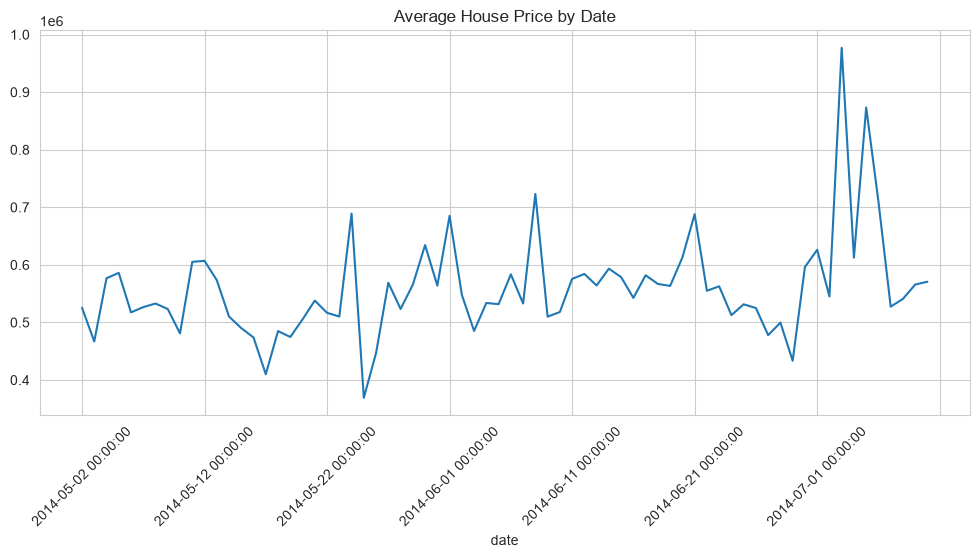

In [13]:
df.groupby("date")["price"].mean().plot(figsize=(12,5))
plt.title("Average House Price by Date")
plt.xticks(rotation=45)
plt.show()

In [14]:
df.drop(columns='date', inplace=True)

In [15]:
# Price
print(f"\n1. Houses with Price = 0 : {(df['price'] == 0).sum()}")
if (df['price'] == 0).sum() > 0:
    display(df[df['price'] == 0])

# Bedrooms
print(f"\n2. Houses with Bedrooms = 0 : {(df['bedrooms'] == 0).sum()}")
if (df['bedrooms'] == 0).sum() > 0:
    display(df[df['bedrooms'] == 0])

# Bathrooms
print(f"\n3. Houses with Bathrooms = 0 : {(df['bathrooms'] == 0).sum()}")
if (df['bathrooms'] == 0).sum() > 0:
    display(df[df['bathrooms'] == 0])

# Living Area
print(f"\n4. Houses with Living Area <= 0 : {(df['sqft_living'] <= 0).sum()}")
if (df['sqft_living'] <= 0).sum() > 0:
    display(df[df['sqft_living'] <= 0])

# Lot Area
print(f"\n5. Houses with Lot Area <= 0 : {(df['sqft_lot'] <= 0).sum()}")
if (df['sqft_lot'] <= 0).sum() > 0:
    display(df[df['sqft_lot'] <= 0])

# Floors
print(f"\n6. Houses with Floors <= 0 : {(df['floors'] <= 0).sum()}")
if (df['floors'] <= 0).sum() > 0:
    display(df[df['floors'] <= 0])

# Above Ground Area
print(f"\n7. Houses with Above Ground Area <= 0 : {(df['sqft_above'] <= 0).sum()}")
if (df['sqft_above'] <= 0).sum() > 0:
    display(df[df['sqft_above'] <= 0])

# Basement Area
print(f"\n8. Houses with Basement Area < 0 : {(df['sqft_basement'] < 0).sum()}")
if (df['sqft_basement'] < 0).sum() > 0:
    display(df[df['sqft_basement'] < 0])

# Year Built
print(f"\n9. Houses with Invalid Year Built (<1800): {(df['yr_built'] < 1800).sum()}")
if (df['yr_built'] < 1800).sum() > 0:
    display(df[df['yr_built'] < 1800])

# Renovation Year
print(f"\n10. Houses with Future Renovation Year (> Current Year): {(df['yr_renovated'] > 2025).sum()}")
if (df['yr_renovated'] > 2025).sum() > 0:
    display(df[df['yr_renovated'] > 2025])


1. Houses with Price = 0 : 49


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
4354,0.0,3.0,1.75,1490,10125,1.0,0,0,4,1490,0,1962,0,3911 S 328th St,Federal Way,WA 98001,USA
4356,0.0,4.0,2.75,2600,5390,1.0,0,0,4,1300,1300,1960,2001,2120 31st Ave W,Seattle,WA 98199,USA
4357,0.0,6.0,2.75,3200,9200,1.0,0,2,4,1600,1600,1953,1983,12271 Marine View Dr SW,Burien,WA 98146,USA
4358,0.0,5.0,3.50,3480,36615,2.0,0,0,4,2490,990,1983,0,21809 SE 38th Pl,Issaquah,WA 98075,USA
4361,0.0,5.0,1.50,1500,7112,1.0,0,0,5,760,740,1920,0,14901-14999 12th Ave SW,Burien,WA 98166,USA
4362,0.0,4.0,4.00,3680,18804,2.0,0,0,3,3680,0,1990,2009,1223-1237 244th Ave NE,Sammamish,WA 98074,USA
4374,0.0,2.0,2.50,2200,188200,1.0,0,3,3,2200,0,2007,0,39612 254th Ave SE,Enumclaw,WA 98022,USA
4376,0.0,4.0,2.25,2170,10500,1.0,0,2,4,1270,900,1960,2001,216 SW 183rd St,Normandy Park,WA 98166,USA
4382,0.0,5.0,4.50,4630,6324,2.0,0,0,3,3210,1420,2006,0,6925 Oakmont Ave SE,Snoqualmie,WA 98065,USA
4383,0.0,5.0,4.00,4430,9000,2.0,0,0,3,4430,0,2013,1923,9235 NE 5th St,Bellevue,WA 98004,USA



2. Houses with Bedrooms = 0 : 2


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
2365,1095000.0,0.0,0.0,3064,4764,3.5,0,2,3,3064,0,1990,2009,814 E Howe St,Seattle,WA 98102,USA
3209,1295648.0,0.0,0.0,4810,28008,2.0,0,0,3,4810,0,1990,2009,20418 NE 64th Pl,Redmond,WA 98053,USA



3. Houses with Bathrooms = 0 : 2


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
2365,1095000.0,0.0,0.0,3064,4764,3.5,0,2,3,3064,0,1990,2009,814 E Howe St,Seattle,WA 98102,USA
3209,1295648.0,0.0,0.0,4810,28008,2.0,0,0,3,4810,0,1990,2009,20418 NE 64th Pl,Redmond,WA 98053,USA



4. Houses with Living Area <= 0 : 0

5. Houses with Lot Area <= 0 : 0

6. Houses with Floors <= 0 : 0

7. Houses with Above Ground Area <= 0 : 0

8. Houses with Basement Area < 0 : 0

9. Houses with Invalid Year Built (<1800): 0

10. Houses with Future Renovation Year (> Current Year): 0


In [16]:
# Remove records with zero price
df = df[df["price"] > 0]

# Remove houses with zero bedrooms or zero bathrooms
df = df[(df['bedrooms'] > 0) & (df['bathrooms'] > 0)]

# Reset index
df.reset_index(drop=True, inplace=True)

### 🔍 Observation

The dataset was successfully preprocessed to ensure data quality before analysis. The `date` column was removed as it covered only a short time period and provided limited predictive information. No missing values or duplicate records were found. During data validation, **49 records with a house price of 0** and **2 records with both 0 bedrooms and 0 bathrooms** were identified as invalid and removed. The resulting dataset is clean, consistent, and ready for exploratory data analysis (EDA) and model development.

## 🎯 6. Exploratory Data Analysis (EDA)

Now that the data is clean, let's visually explore relationships between
features and the target variable (`price`).


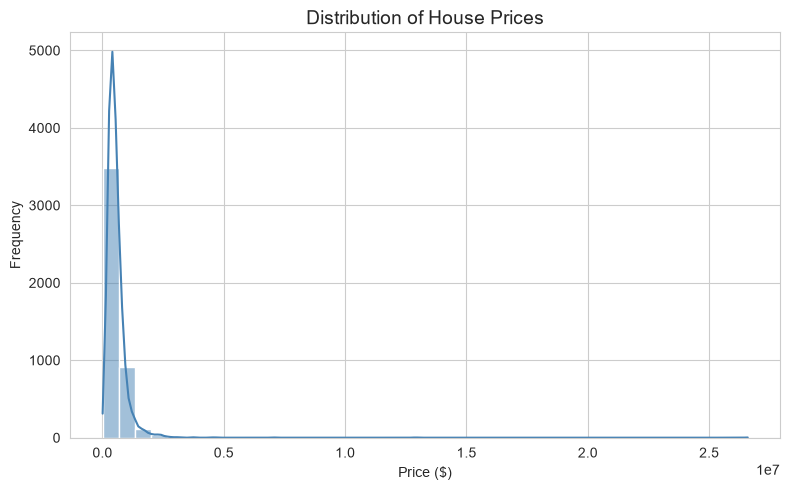

In [17]:
# Histogram of Price
plt.figure(figsize=(8, 5))

sns.histplot(df["price"], bins=40, kde=True, color="steelblue")

plt.title("Distribution of House Prices", fontsize=14)
plt.xlabel("Price ($)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("../images/price_histogram.png", dpi=120)
plt.show()

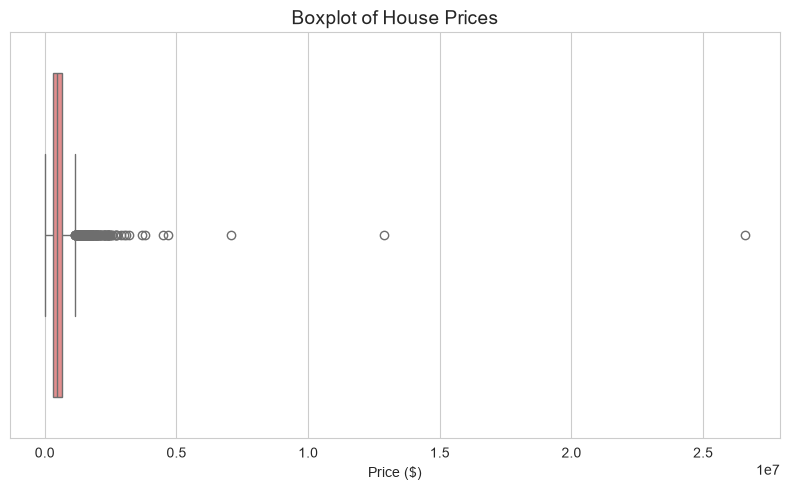

In [18]:
# Boxplot of Price (helps visualize spread and potential outliers)
plt.figure(figsize=(8, 5))
sns.boxplot(x=df["price"], color="lightcoral")
plt.title("Boxplot of House Prices", fontsize=14)
plt.xlabel("Price ($)")
plt.tight_layout()
plt.savefig("../images/price_boxplot.png", dpi=120)
plt.show()

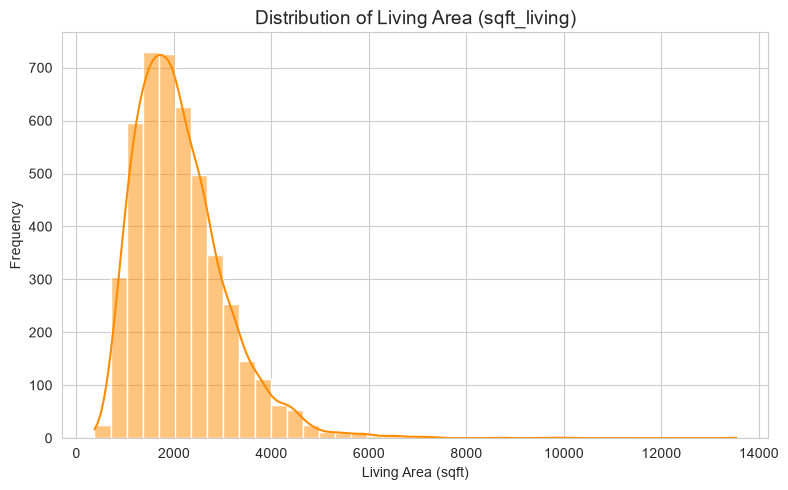

In [19]:
# Distribution plot for sqft_living
plt.figure(figsize=(8, 5))
sns.histplot(df["sqft_living"], bins=40, kde=True, color="darkorange")
plt.title("Distribution of Living Area (sqft_living)", fontsize=14)
plt.xlabel("Living Area (sqft)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("../images/sqft_living_distribution.png", dpi=120)
plt.show()

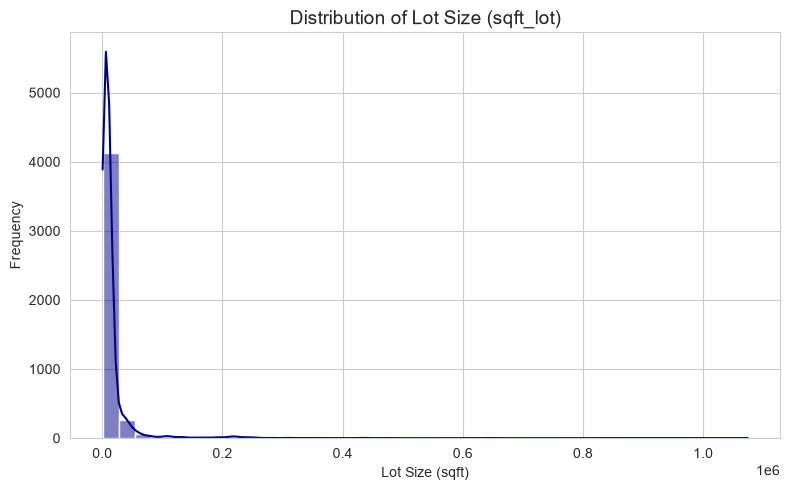

In [20]:
# Distribution plot for lot size (sqft_lot)
plt.figure(figsize=(8, 5))
sns.histplot(df["sqft_lot"], bins=40, kde=True, color="darkblue")
plt.title("Distribution of Lot Size (sqft_lot)", fontsize=14)
plt.xlabel("Lot Size (sqft)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("../images/sqft_lot_distribution.png", dpi=120)
plt.show()

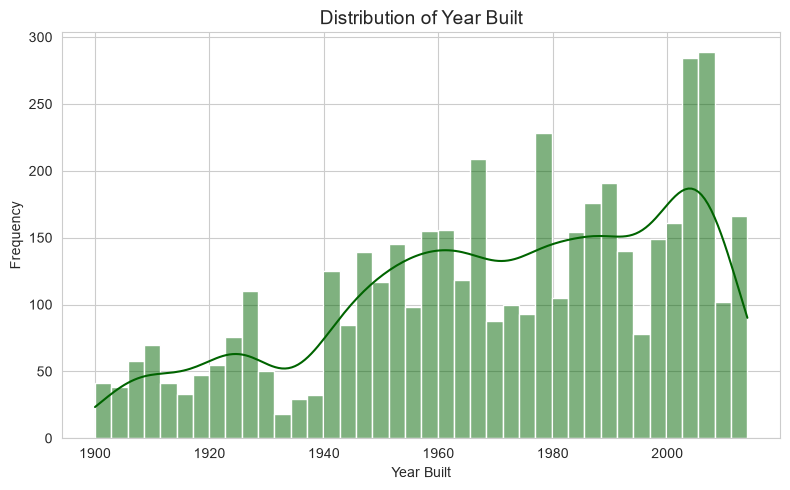

In [21]:
# Distribution plot for year built
plt.figure(figsize=(8, 5))
sns.histplot(df["yr_built"], bins=40, kde=True, color="darkgreen")
plt.title("Distribution of Year Built", fontsize=14)
plt.xlabel("Year Built")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("../images/year_built_distribution.png", dpi=120)
plt.show()

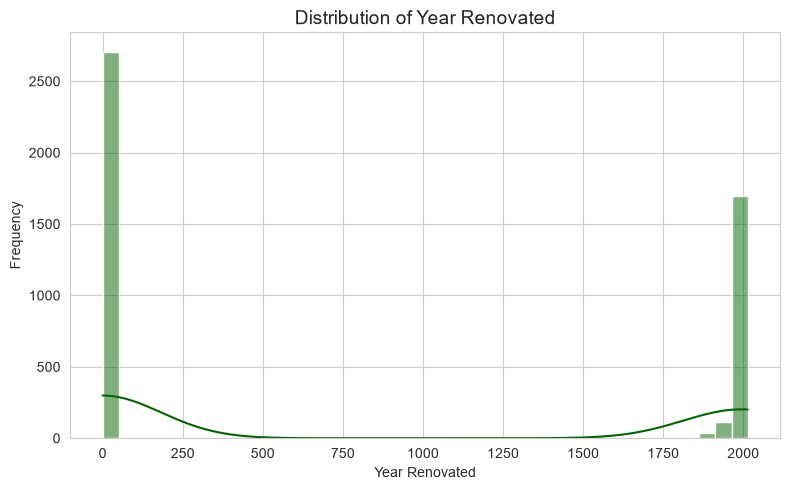

In [22]:
# Distribution plot for year renovated
plt.figure(figsize=(8, 5))
sns.histplot(df["yr_renovated"], bins=40, kde=True, color="darkgreen")
plt.title("Distribution of Year Renovated", fontsize=14)
plt.xlabel("Year Renovated")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("../images/year_renovated_distribution.png", dpi=120)
plt.show()

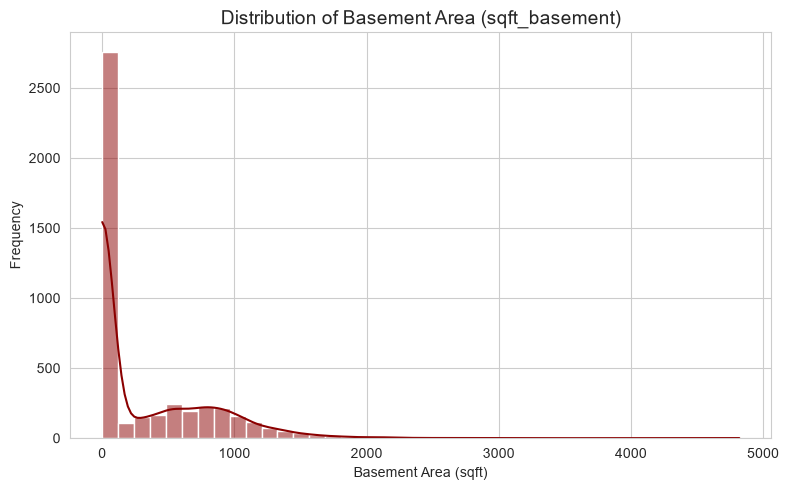

In [23]:
# Distribution plot for Basement Area (sqft_basement)
plt.figure(figsize=(8, 5))
sns.histplot(df["sqft_basement"], bins=40, kde=True, color="darkred")
plt.title("Distribution of Basement Area (sqft_basement)", fontsize=14)
plt.xlabel("Basement Area (sqft)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("../images/sqft_basement_distribution.png", dpi=120)
plt.show()

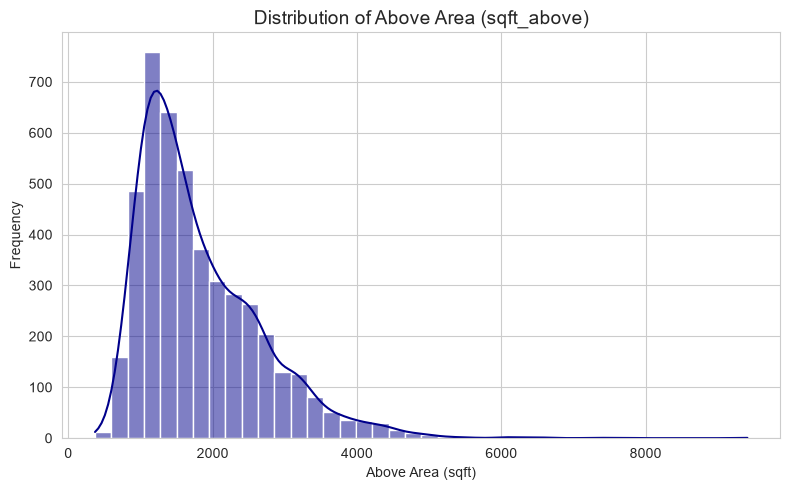

In [24]:
# Distribution plot for Above Area (sqft_above)
plt.figure(figsize=(8, 5))
sns.histplot(df["sqft_above"], bins=40, kde=True, color="darkblue")
plt.title("Distribution of Above Area (sqft_above)", fontsize=14)
plt.xlabel("Above Area (sqft)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("../images/sqft_above_distribution.png", dpi=120)
plt.show()

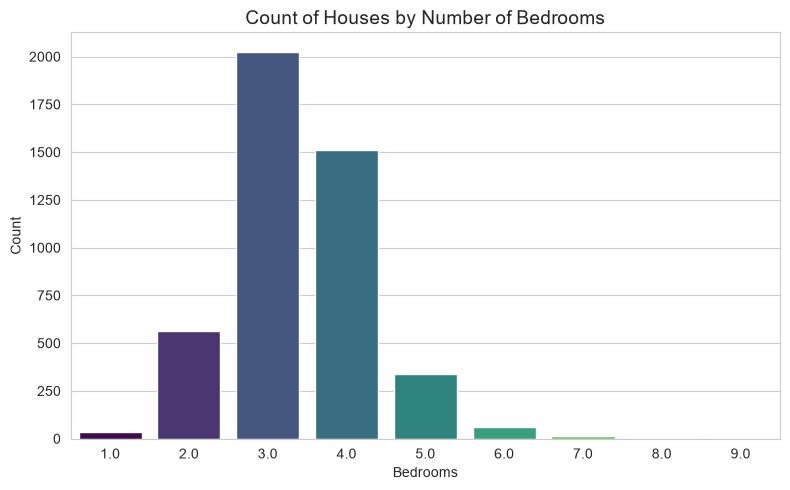

In [25]:
# Countplot of Bedrooms
plt.figure(figsize=(8, 5))
sns.countplot(x="bedrooms", data=df, hue="bedrooms", palette="viridis", legend=False)
plt.title("Count of Houses by Number of Bedrooms", fontsize=14)
plt.xlabel("Bedrooms")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../images/bedrooms_countplot.png", dpi=120)
plt.show()

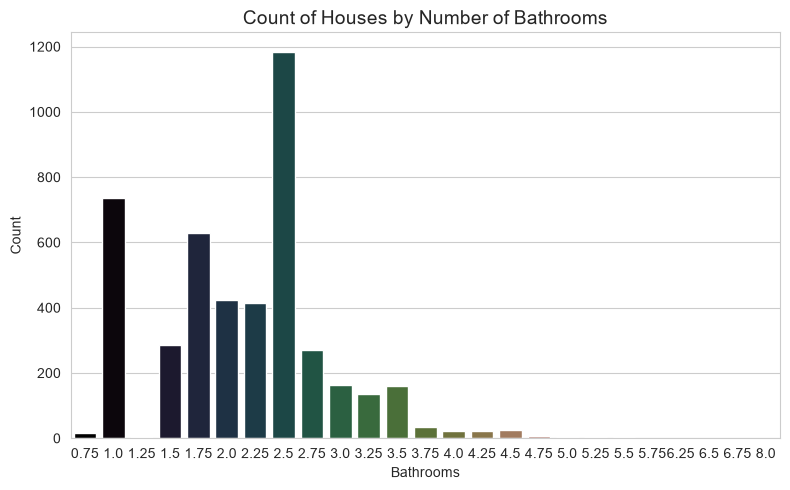

In [26]:
# Countplot of Bathrooms
plt.figure(figsize=(8, 5))
sns.countplot(x="bathrooms", data=df, hue="bathrooms", palette="cubehelix", legend=False)
plt.title("Count of Houses by Number of Bathrooms", fontsize=14)
plt.xlabel("Bathrooms")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../images/bathrooms_countplot.png", dpi=120)
plt.show()

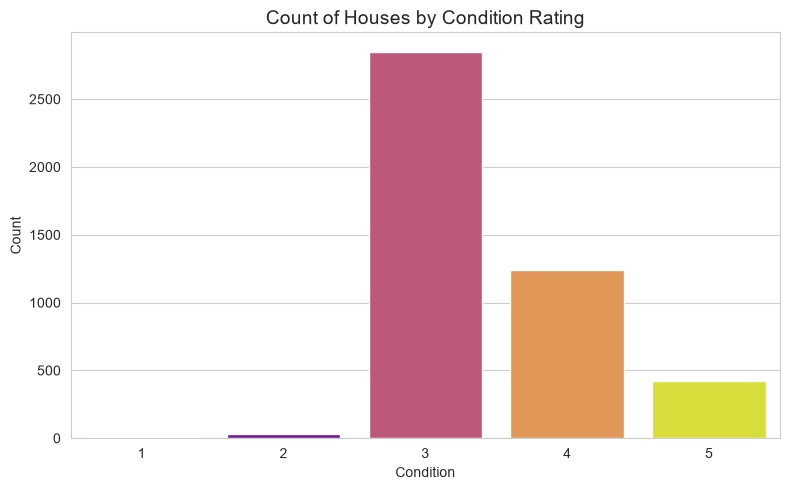

In [27]:
# Countplot of Condition
plt.figure(figsize=(8, 5))
sns.countplot(x="condition", data=df, hue="condition", palette="plasma", legend=False)
plt.title("Count of Houses by Condition Rating", fontsize=14)
plt.xlabel("Condition")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../images/condition_countplot.png", dpi=120)
plt.show()


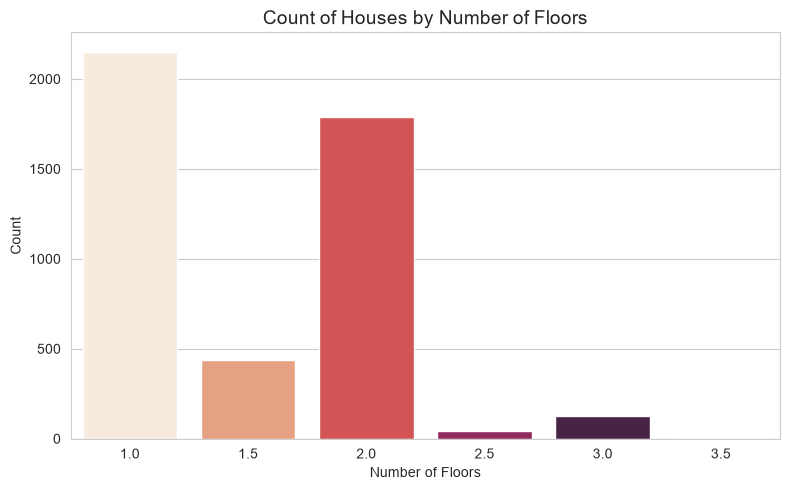

In [28]:
# Countplot of Floors
plt.figure(figsize=(8, 5))
sns.countplot(x="floors", data=df, hue="floors", palette="rocket_r", legend=False)
plt.title("Count of Houses by Number of Floors", fontsize=14)
plt.xlabel("Number of Floors")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../images/floors_countplot.png", dpi=120)
plt.show()


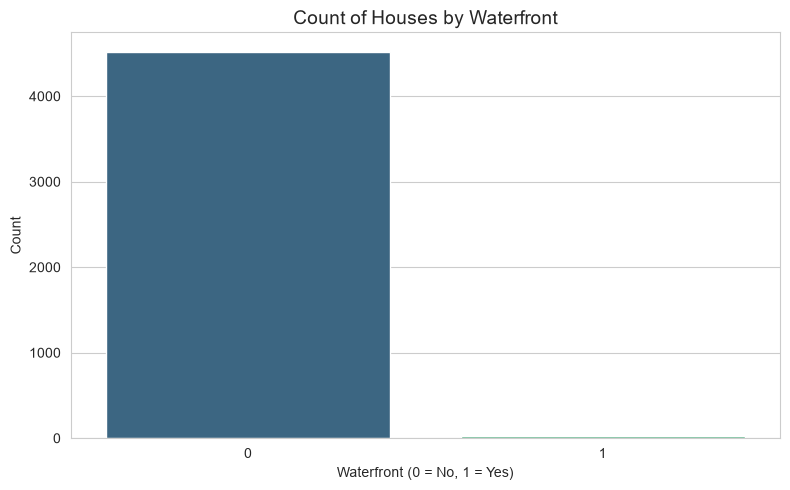

In [29]:
# Countplot of Waterfront
plt.figure(figsize=(8, 5))
sns.countplot(
    x="waterfront",
    data=df,
    hue="waterfront",
    palette="viridis",
    legend=False
)

plt.title("Count of Houses by Waterfront", fontsize=14)
plt.xlabel("Waterfront (0 = No, 1 = Yes)")
plt.ylabel("Count")

plt.tight_layout()
plt.savefig("../images/waterfront_countplot.png", dpi=120)
plt.show()

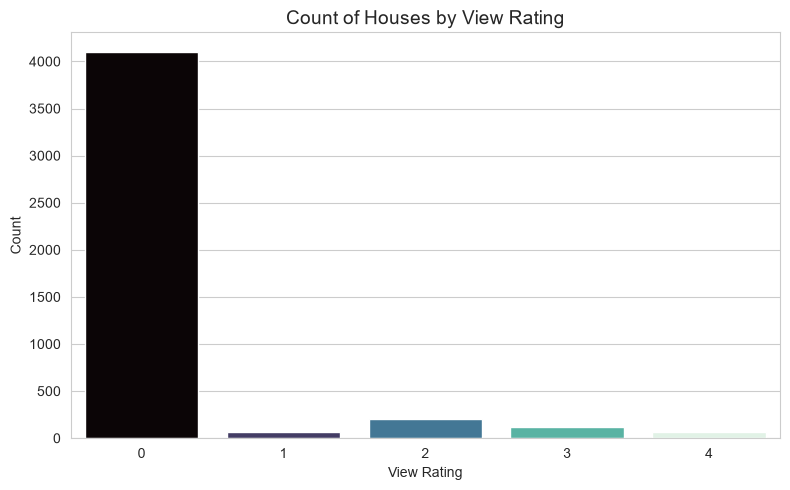

In [30]:
# Countplot of View Rating
plt.figure(figsize=(8, 5))
sns.countplot(
    x="view",
    data=df,
    hue="view",
    palette="mako",
    legend=False
)

plt.title("Count of Houses by View Rating", fontsize=14)
plt.xlabel("View Rating")
plt.ylabel("Count")

plt.tight_layout()
plt.savefig("../images/view_countplot.png", dpi=120)
plt.show()

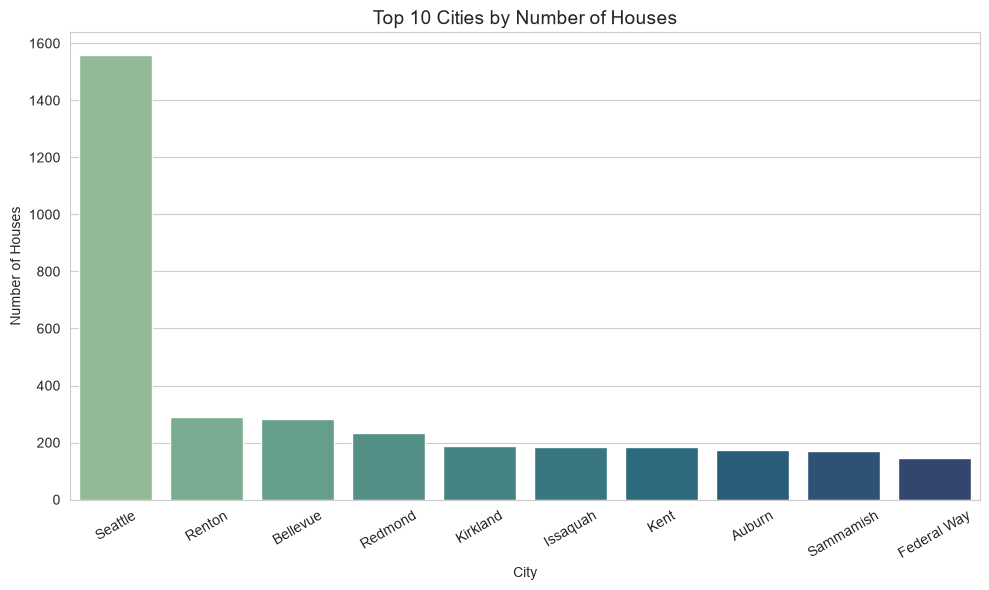

In [31]:
# Top 10 Cities by Number of Houses
top_cities = df["city"].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=top_cities.index,
    y=top_cities.values,
    hue=top_cities.index,
    palette="crest",
    legend=False
)

plt.title("Top 10 Cities by Number of Houses", fontsize=14)
plt.xlabel("City")
plt.ylabel("Number of Houses")

plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig("../images/top10_cities.png", dpi=120)
plt.show()

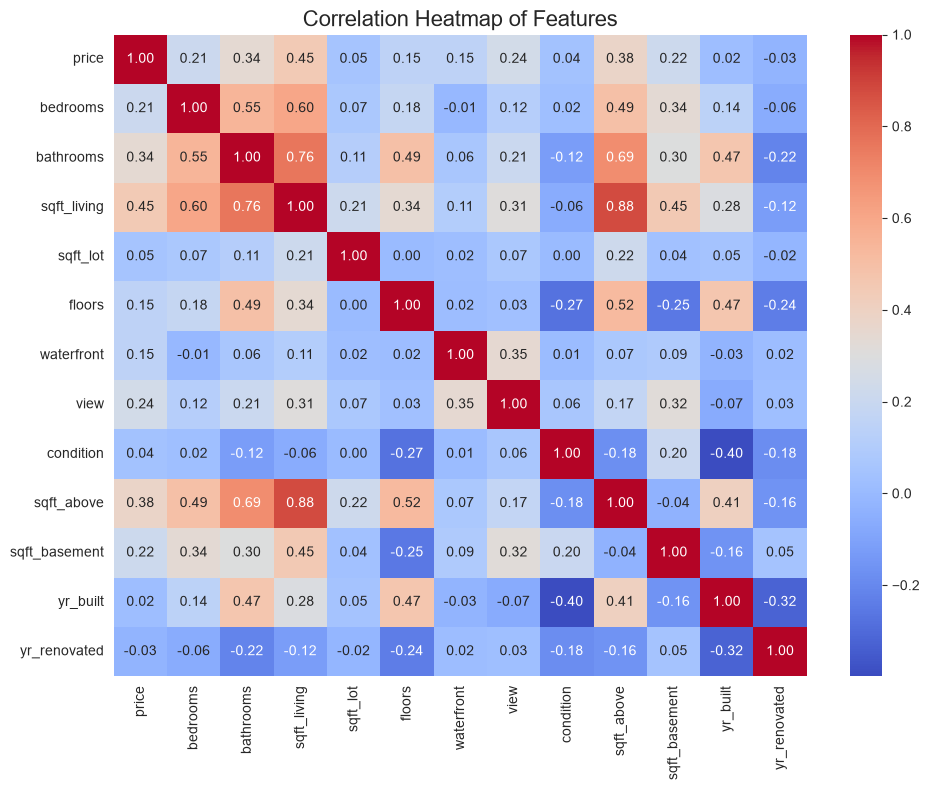

In [32]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Heatmap of Features", fontsize=16)
plt.tight_layout()
plt.savefig("../images/correlation_heatmap.png", dpi=120)
plt.show()

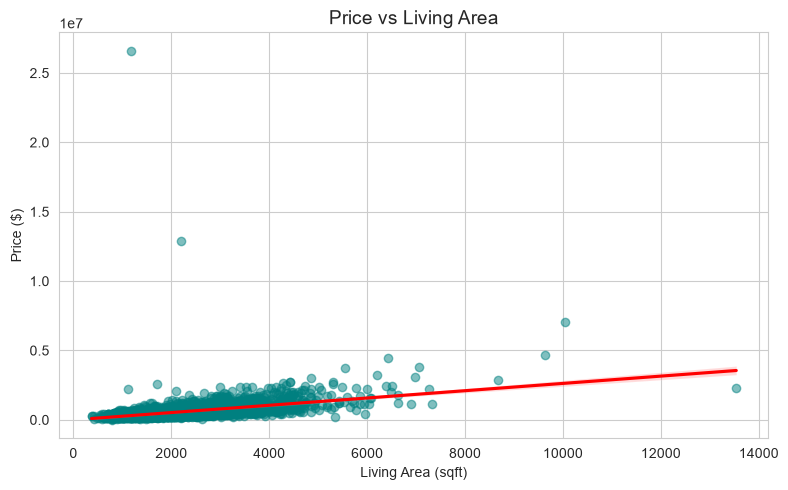

In [33]:
# Scatter/Reg Plot: Price vs Living Area
plt.figure(figsize=(8, 5))
sns.regplot(x="sqft_living", y="price", data=df,scatter_kws={"alpha": 0.5},
    line_kws={"color": "red"}, color="teal")
plt.title("Price vs Living Area", fontsize=14)
plt.xlabel("Living Area (sqft)")
plt.ylabel("Price ($)")
plt.tight_layout()
plt.savefig("../images/price_vs_sqft_living.png", dpi=120)
plt.show()

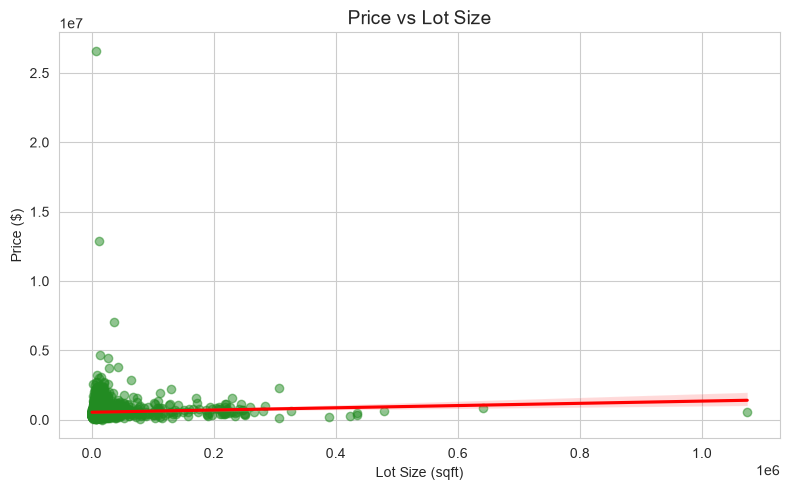

In [34]:
# Scatter/Reg Plot: Price vs Lot Size
plt.figure(figsize=(8, 5))
sns.regplot(
    x="sqft_lot",
    y="price",
    data=df,
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red"},
    color="forestgreen"
)

plt.title("Price vs Lot Size", fontsize=14)
plt.xlabel("Lot Size (sqft)")
plt.ylabel("Price ($)")

plt.tight_layout()
plt.savefig("../images/price_vs_sqft_lot.png", dpi=120)
plt.show()

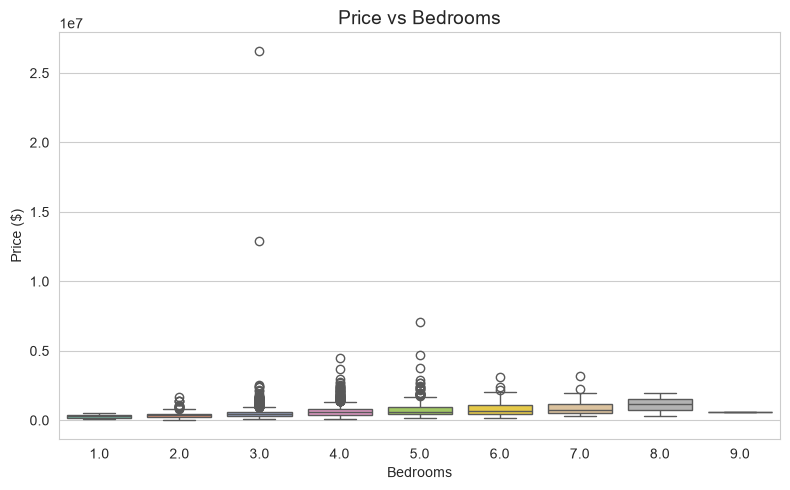

In [35]:
# Box Plot: Price vs Bedrooms
plt.figure(figsize=(8, 5))
sns.boxplot(x="bedrooms", y="price", data=df, hue="bedrooms", palette="Set2", legend=False)
plt.title("Price vs Bedrooms", fontsize=14)
plt.xlabel("Bedrooms")
plt.ylabel("Price ($)")
plt.tight_layout()
plt.savefig("../images/price_vs_bedrooms.png", dpi=120)
plt.show()


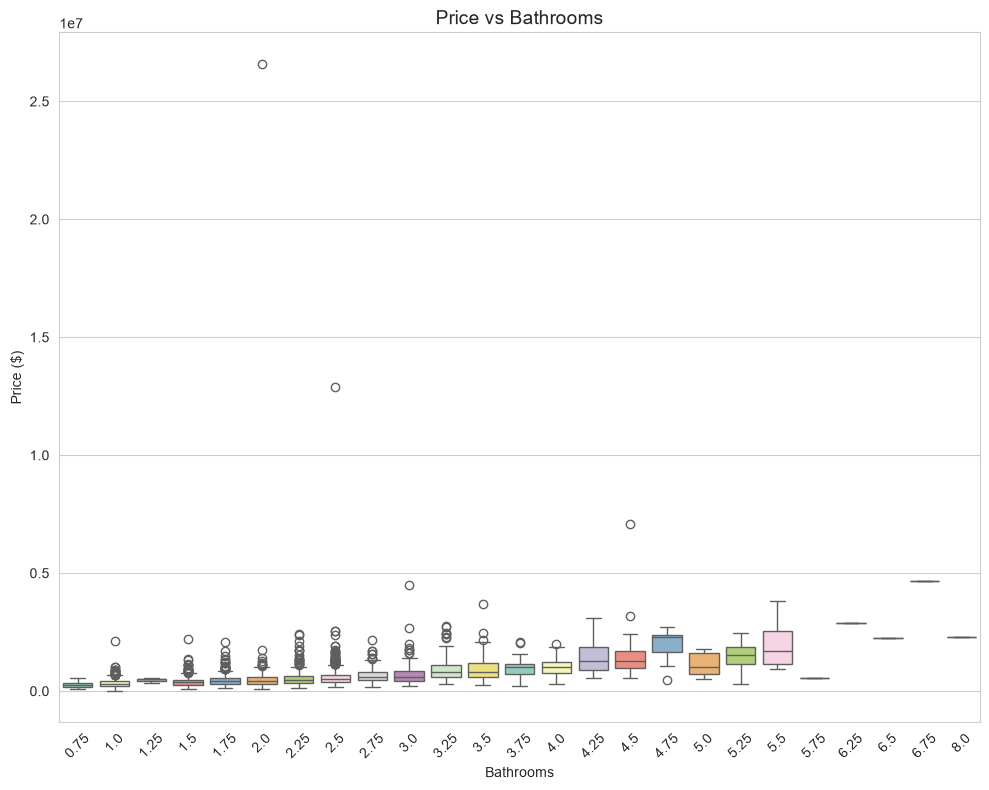

In [36]:
# Box Plot: Price vs Bathrooms
plt.figure(figsize=(10,8))
sns.boxplot(x="bathrooms", y="price", data=df, hue="bathrooms", palette="Set3", legend=False)
plt.title("Price vs Bathrooms", fontsize=14)
plt.xlabel("Bathrooms")
plt.ylabel("Price ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../images/price_vs_bathrooms.png", dpi=120)
plt.show()


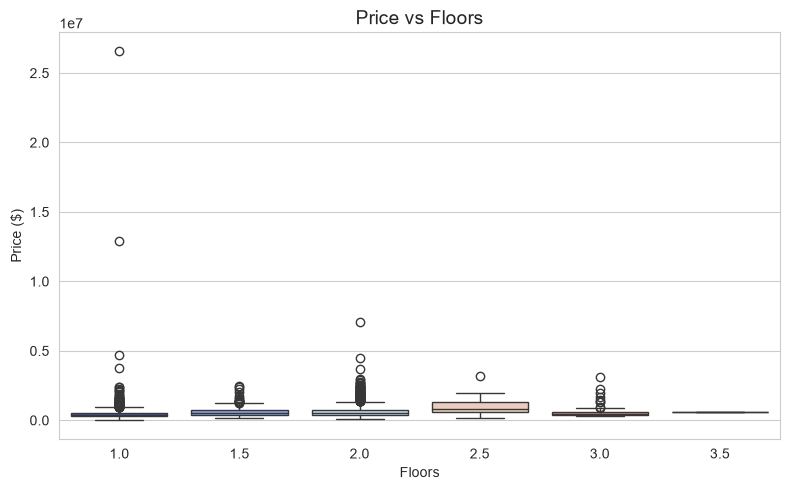

In [37]:
# Box Plot: Price vs Floors
plt.figure(figsize=(8, 5))
sns.boxplot(x="floors", y="price", data=df, hue="floors", palette="coolwarm", legend=False)
plt.title("Price vs Floors", fontsize=14)
plt.xlabel("Floors")
plt.ylabel("Price ($)")
plt.tight_layout()
plt.savefig("../images/price_vs_floors.png", dpi=120)
plt.show()


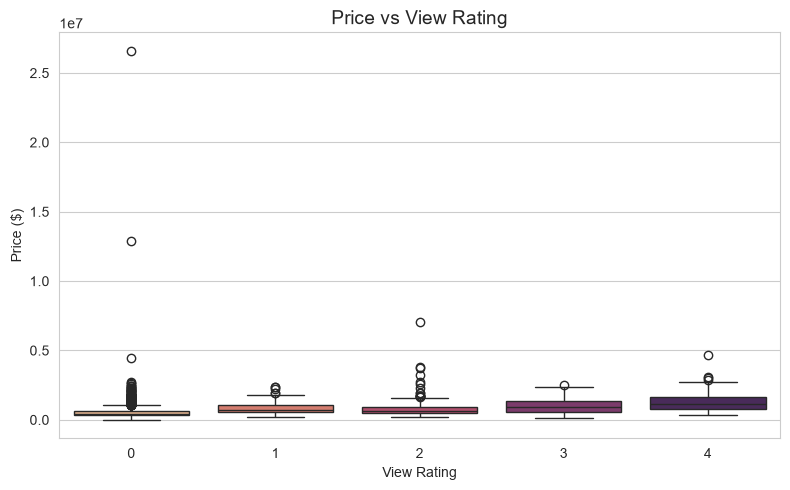

In [38]:
# Box Plot: Price vs View
plt.figure(figsize=(8, 5))
sns.boxplot(x="view", y="price", data=df, hue="view", palette="flare", legend=False)
plt.title("Price vs View Rating", fontsize=14)
plt.xlabel("View Rating")
plt.ylabel("Price ($)")
plt.tight_layout()
plt.savefig("../images/price_vs_view.png", dpi=120)
plt.show()


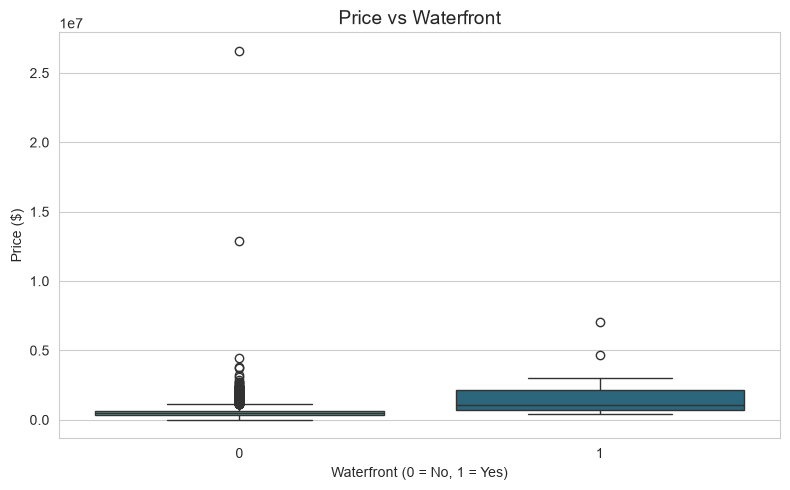

In [39]:
# Box Plot: Price vs Waterfront
plt.figure(figsize=(8, 5))
sns.boxplot(x="waterfront", y="price", data=df, hue="waterfront", palette="crest", legend=False)
plt.title("Price vs Waterfront", fontsize=14)
plt.xlabel("Waterfront (0 = No, 1 = Yes)")
plt.ylabel("Price ($)")
plt.tight_layout()
plt.savefig("../images/price_vs_waterfront.png", dpi=120)
plt.show()


### 📌 EDA Summary

The exploratory data analysis revealed several important insights about the housing dataset:

- House prices are **positively skewed**, with a few extremely expensive properties creating a long right tail in the distribution.
- The boxplot confirms the presence of **extreme outliers** in house prices, which will be addressed during the outlier treatment stage.
- Most houses have a **living area between 1,000 and 3,000 square feet**, while both living area and above-ground area exhibit positively skewed distributions.
- **Lot size** is highly right-skewed due to a small number of properties with exceptionally large land areas.
- A large proportion of houses **do not have a basement**, while basement sizes for the remaining houses are positively skewed.
- Most properties in the dataset were built **after the mid-20th century**, indicating a higher concentration of relatively modern houses.
- The majority of houses contain **3–4 bedrooms**, **2–2.5 bathrooms**, and **1–2 floors**, representing typical family homes.
- Most houses are in **average condition (Condition = 3)**, while houses in very poor or excellent condition are comparatively rare.
- The dataset is highly imbalanced with respect to **waterfront access** and **view rating**, as most houses do not have waterfront access or a significant scenic view.
- **Seattle** contains the largest number of properties in the dataset, followed by cities such as Renton, Bellevue, and Redmond.
- Correlation analysis shows that **sqft_living**, **sqft_above**, **bathrooms**, and **bedrooms** have the strongest positive relationships with house price.
- Relationship plots indicate that **living area**, **above-ground area**, **bathrooms**, **bedrooms**, **waterfront access**, and **view rating** positively influence house prices, whereas **lot size** exhibits only a weak positive relationship.

Overall, the exploratory analysis provides a clear understanding of the dataset, identifies the most influential features affecting house prices, and highlights the presence of outliers that should be treated before building and evaluating the regression models.

## 📦 7. Outlier Detection & Treatment
We use **boxplots** and the **IQR (Interquartile Range) method** to detect outliers in the
`price` column. Outliers can distort the regression line since Linear Regression is
sensitive to extreme values.

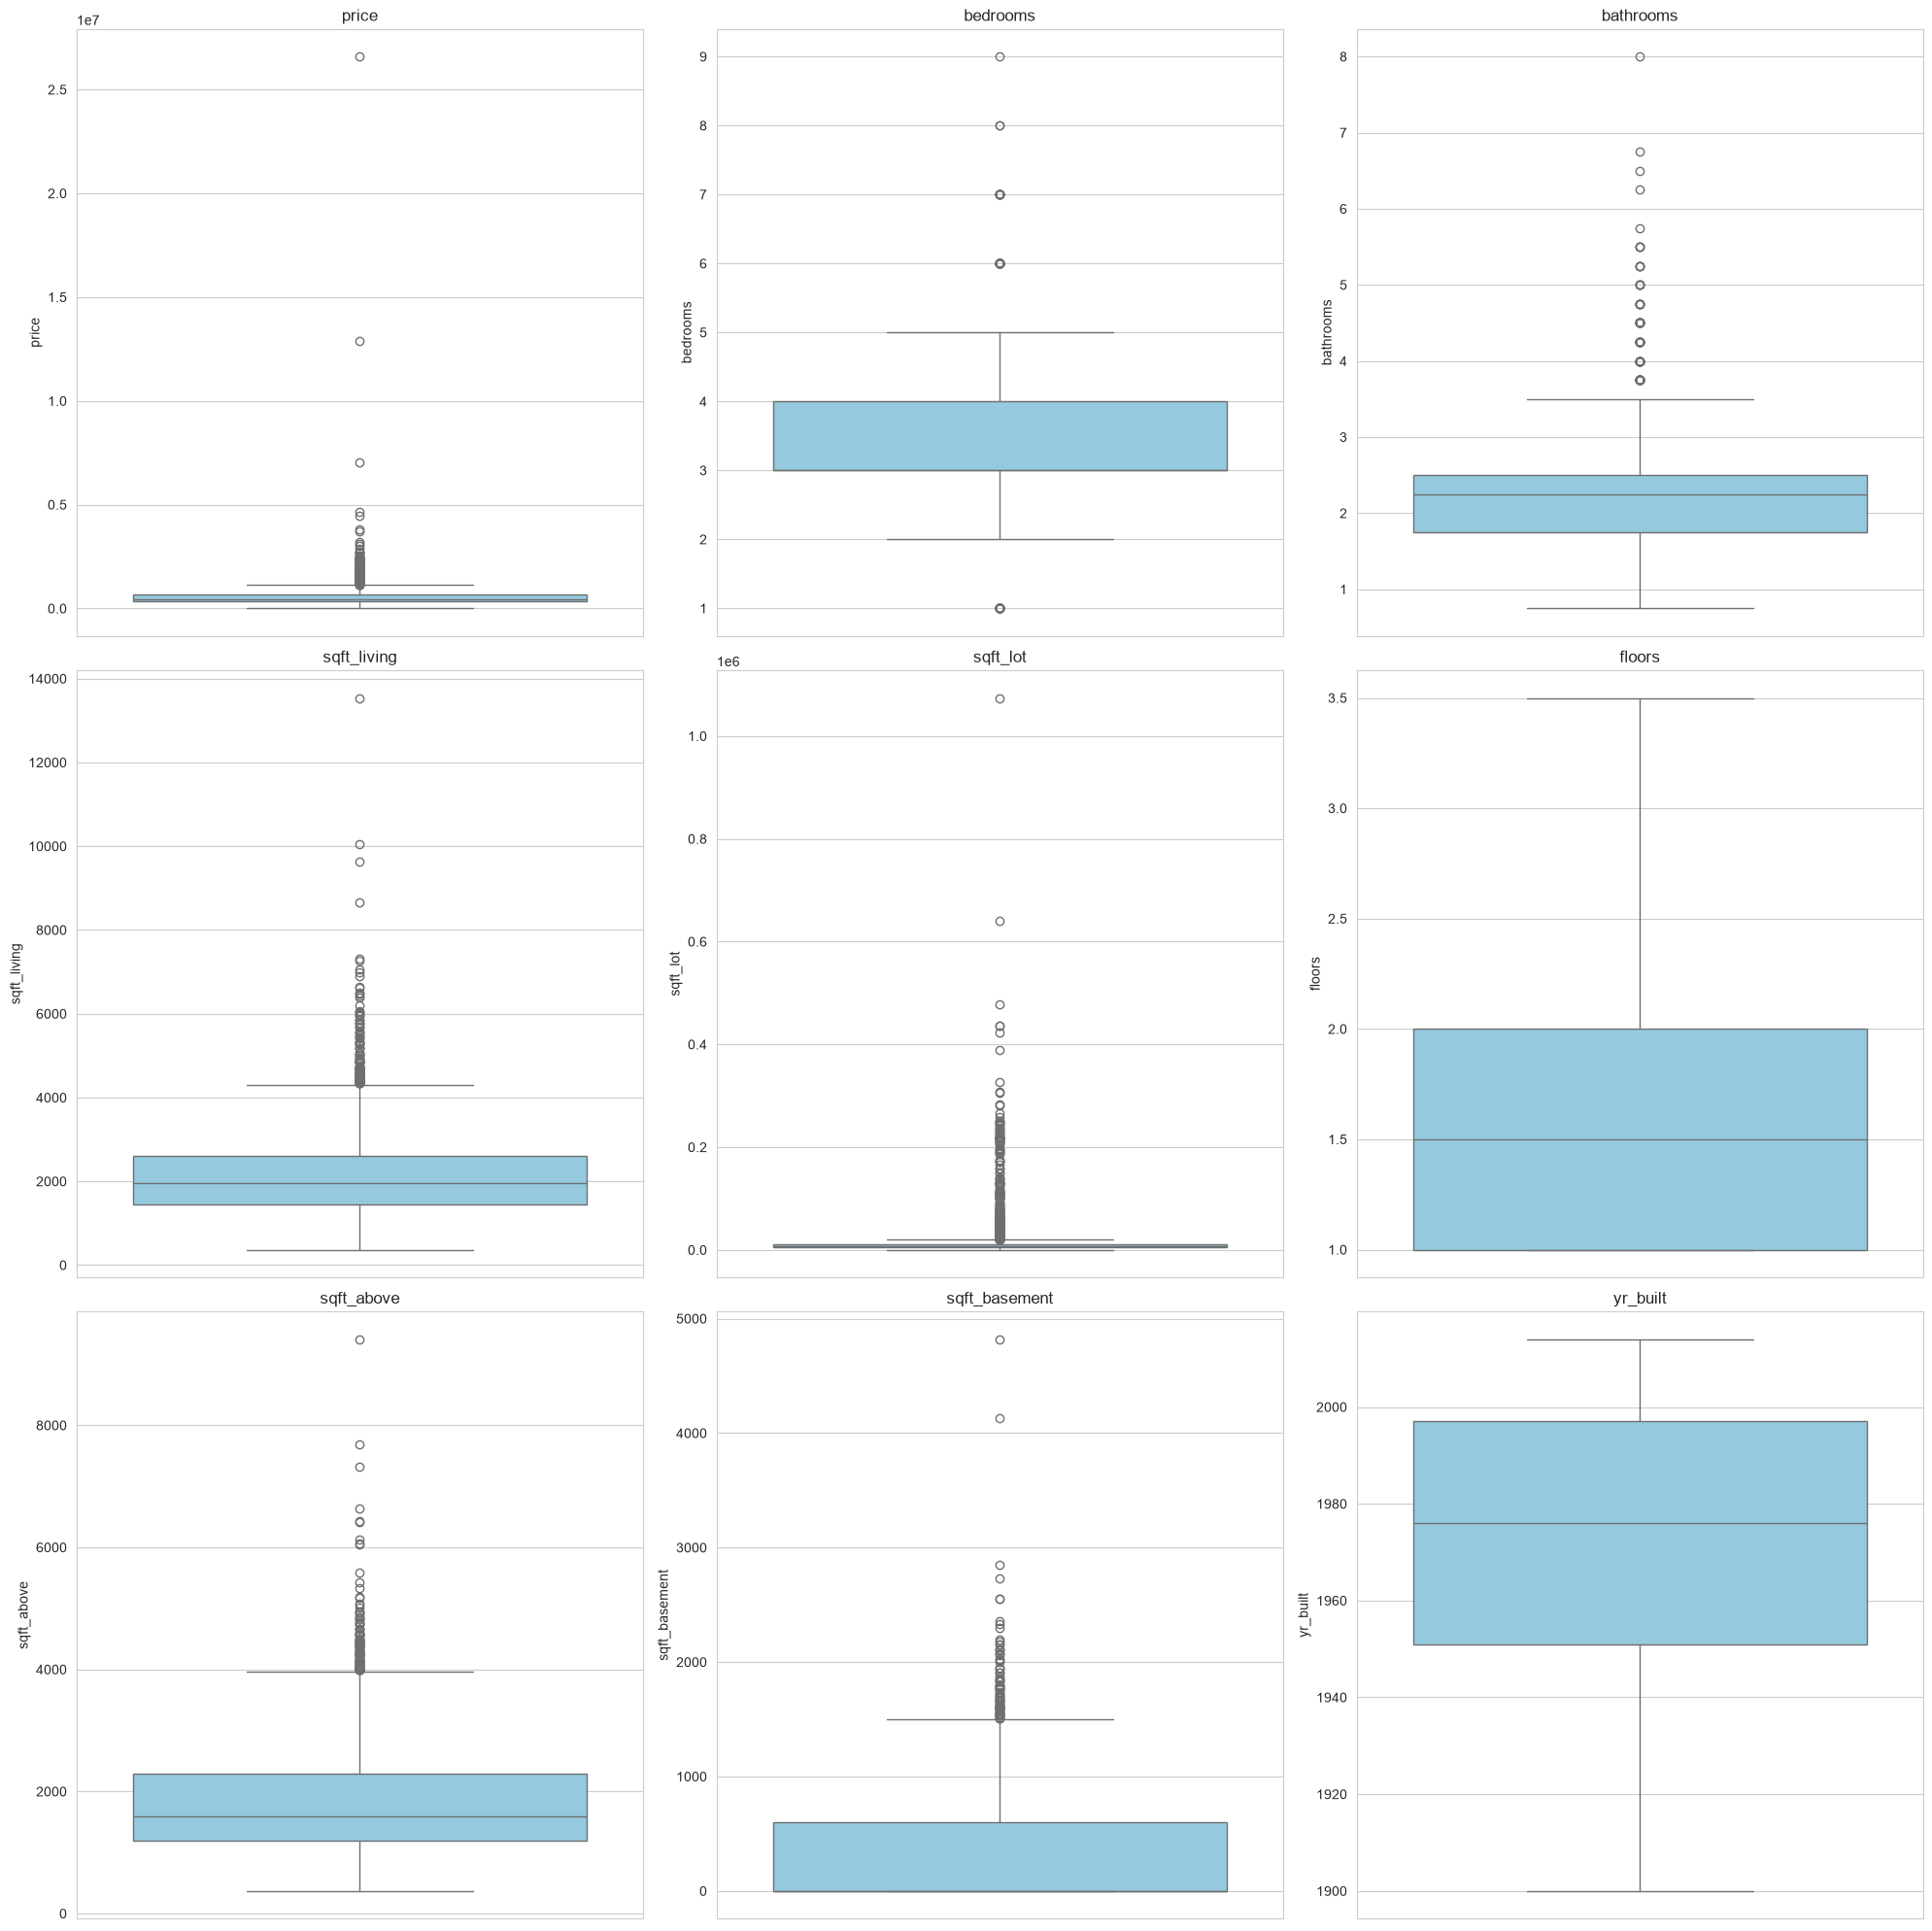

In [40]:
numerical_cols = [
    'price',
    'bedrooms',
    'bathrooms',
    'sqft_living',
    'sqft_lot',
    'floors',
    'sqft_above',
    'sqft_basement',
    'yr_built'
]
plt.figure(figsize=(20, 20))

for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(y=df[col], color="skyblue")
    plt.title(col)

plt.tight_layout()
plt.savefig("../images/all_boxplots.png", dpi=200)
plt.show()

In [41]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[(data[column] < lower) | (data[column] > upper)]

    return len(outliers)


print("Outlier Report\n")

for col in numerical_cols:
    print(f"{col:15} : {detect_outliers_iqr(df, col)} ({detect_outliers_iqr(df, col)/ len(df)*100:.2f}% of the data)")

Outlier Report

price           : 239 (5.25% of the data)
bedrooms        : 113 (2.48% of the data)
bathrooms       : 128 (2.81% of the data)
sqft_living     : 127 (2.79% of the data)
sqft_lot        : 539 (11.85% of the data)
floors          : 0 (0.00% of the data)
sqft_above      : 110 (2.42% of the data)
sqft_basement   : 83 (1.82% of the data)
yr_built        : 0 (0.00% of the data)


### 🔍 Observation

**Effect of Outliers:**

Outliers can influence the regression line and increase error metrics such as **MSE** and **RMSE** because these metrics give greater weight to large prediction errors. However, the identified outliers in this dataset represent **valid high-value and luxury properties** rather than erroneous records. Therefore, they were retained to preserve valuable information and maintain the real-world distribution of house prices.

## 🛠️ 8. Feature Construction

Construct new features from the existing variables to capture additional information and improve the predictive performance of the regression model.

In [44]:
current_year = pd.Timestamp.now().year

df["house_age"] = current_year - df["yr_built"]

df["is_renovated"] = (df["yr_renovated"] != 0).astype(int)

df["living_lot_ratio"] = df["sqft_living"] / df["sqft_lot"].replace(0, 1)

df["total_rooms"] = df["bedrooms"] + df["bathrooms"]

### 🔍 Observation

To enrich the dataset, several new features were constructed from the existing variables. **`house_age`** captures the age of the property, **`is_renovated`** indicates whether a house has been renovated, **`living_lot_ratio`** measures the proportion of the lot occupied by the living area, and **`total_rooms`** represents the overall size of the house. These engineered features provide additional information that may improve the model's ability to predict house prices.

## 🎯 9. Feature Selection

Select the most relevant features for predicting house prices by removing non-informative columns and preparing the dataset for machine learning.

In [47]:
# Display all columns
df.columns

Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement',
       'yr_built', 'yr_renovated', 'street', 'city', 'statezip', 'country',
       'house_age', 'is_renovated', 'living_lot_ratio', 'total_rooms'],
      dtype='str')

In [48]:
# Check unique values and distributions for geographic features
print(f"Unique cities: {df['city'].nunique()}")
print(f"Unique zip codes: {df['statezip'].nunique()}")
print(f"Unique streets: {df['street'].nunique()}")

print("\nCountry distribution:")
print(df['country'].value_counts())

Unique cities: 44
Unique zip codes: 77
Unique streets: 4474

Country distribution:
country
USA    4549
Name: count, dtype: int64


In [50]:
columns_to_drop = [
    "street",
    "country",
    "yr_built",
    "yr_renovated"
]
df.drop(columns=columns_to_drop, inplace=True)

In [51]:
print("Remaining columns:")
print(df.columns.tolist())

Remaining columns:
['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'city', 'statezip', 'house_age', 'is_renovated', 'living_lot_ratio', 'total_rooms']


### 🔍 Observation

Feature selection was performed after feature construction to retain the most informative variables for house price prediction. The **`street`** and **`country`** columns were removed because they provided little predictive value, while **`yr_built`** and **`yr_renovated`** were replaced by the engineered features **`house_age`** and **`is_renovated`**, respectively. The remaining features provide a balanced representation of property characteristics, location, and engineered information for model training.

## 🔢 10. Feature Encoding

Convert categorical features into numerical representations using One-Hot Encoding to prepare the dataset for machine learning algorithms.

In [52]:
# One-Hot Encode categorical features
df_encoded = pd.get_dummies(
    df,
    columns=["city", "statezip"],
    drop_first=True,
    dtype=int
)

In [53]:
print("Shape before encoding :", df.shape)
print("Shape after encoding  :", df_encoded.shape)

df_encoded.head()

Shape before encoding : (4549, 17)
Shape after encoding  : (4549, 134)


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,...,statezip_WA 98155,statezip_WA 98166,statezip_WA 98168,statezip_WA 98177,statezip_WA 98178,statezip_WA 98188,statezip_WA 98198,statezip_WA 98199,statezip_WA 98288,statezip_WA 98354
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,...,0,0,0,0,0,0,0,0,0,0
1,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,...,0,0,0,0,0,0,0,0,0,0
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,...,0,0,0,0,0,0,0,0,0,0
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,...,0,0,0,0,0,0,0,0,0,0
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,...,0,0,0,0,0,0,0,0,0,0


In [55]:
df_encoded.to_csv(
    "../data/processed/housing_processed.csv",
    index=False
)

### 🔍 Observation

The categorical features **`city`** and **`statezip`** were transformed using **One-Hot Encoding**. The `drop_first=True` parameter was used to avoid the dummy variable trap and reduce multicollinearity. The processed dataset now contains only numerical features and is ready for model training.

## ✂️ 11. Train-Test Split

Split the processed dataset into training and testing sets to evaluate the performance of the regression models on unseen data.

In [56]:
train_df, test_df = train_test_split(
    df_encoded,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print(f"Training Dataset Shape : {train_df.shape}")
print(f"Testing Dataset Shape  : {test_df.shape}")

Training Dataset Shape : (3639, 134)
Testing Dataset Shape  : (910, 134)


In [58]:
# Save train and test datasets
train_df.to_csv("../data/processed/train.csv", index=False)
test_df.to_csv("../data/processed/test.csv", index=False)

print("Train and Test datasets saved successfully!")

Train and Test datasets saved successfully!


## 12. 📈 Simple Linear Regression

Build a Simple Linear Regression model using **`sqft_living`** as the independent variable to predict house prices. This model serves as a baseline for understanding the relationship between living area and house price before training a Multiple Linear Regression model.

In [67]:
train_df = pd.read_csv("../data/processed/train.csv")
test_df = pd.read_csv("../data/processed/test.csv")

X_train_simple = train_df[["sqft_living"]]
y_train_simple = train_df["price"]

X_test_simple = test_df[["sqft_living"]]
y_test_simple = test_df["price"]

In [68]:
simple_lr = LinearRegression()
simple_lr.fit(X_train_simple, y_train_simple)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[260.66]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['sqft_living']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4402
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [69]:
print(f"Model Equation: price = {simple_lr.coef_[0]:.2f} * sqft_living + {simple_lr.intercept_:.2f}")
print(f"Intercept : {simple_lr.intercept_:.2f}")
print(f"Slope     : {simple_lr.coef_[0]:.2f}")

Model Equation: price = 260.66 * sqft_living + 4401.52
Intercept : 4401.52
Slope     : 260.66


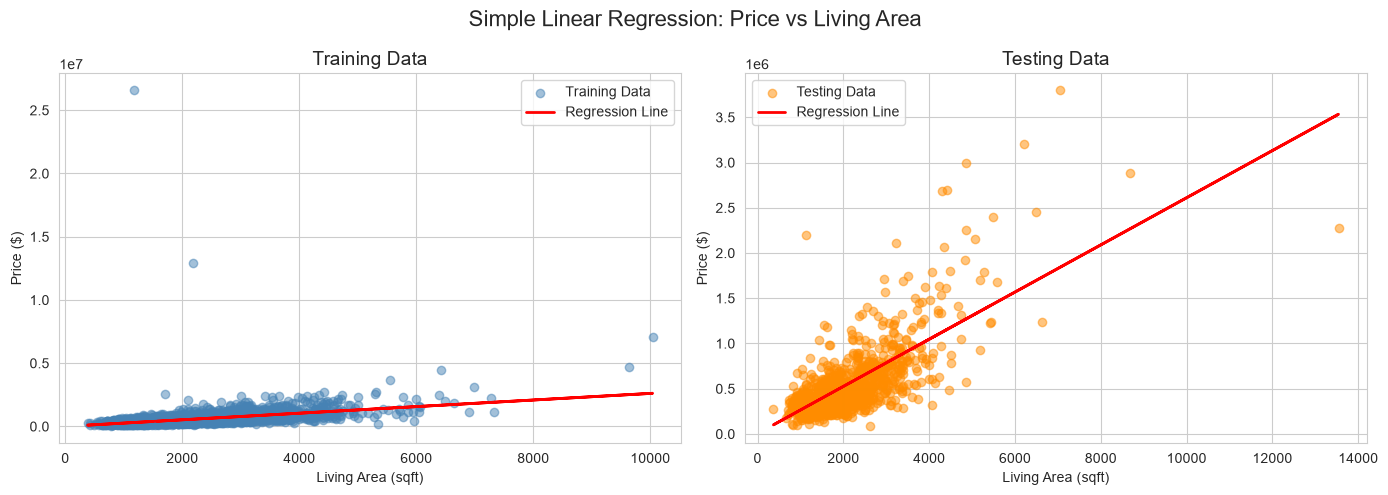

In [71]:
# Make predictions
y_pred_train = simple_lr.predict(X_train_simple)
y_pred_test = simple_lr.predict(X_test_simple)

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ----------------------------
# Training Data
# ----------------------------
axes[0].scatter(
    X_train_simple,
    y_train_simple,
    alpha=0.5,
    color="steelblue",
    label="Training Data"
)

axes[0].plot(
    X_train_simple,
    y_pred_train,
    color="red",
    linewidth=2,
    label="Regression Line"
)

axes[0].set_title("Training Data", fontsize=14)
axes[0].set_xlabel("Living Area (sqft)")
axes[0].set_ylabel("Price ($)")
axes[0].legend()

# ----------------------------
# Testing Data
# ----------------------------
axes[1].scatter(
    X_test_simple,
    y_test_simple,
    alpha=0.5,
    color="darkorange",
    label="Testing Data"
)

axes[1].plot(
    X_test_simple,
    y_pred_test,
    color="red",
    linewidth=2,
    label="Regression Line"
)

axes[1].set_title("Testing Data", fontsize=14)
axes[1].set_xlabel("Living Area (sqft)")
axes[1].set_ylabel("Price ($)")
axes[1].legend()

# ----------------------------
# Save & Show
# ----------------------------
plt.suptitle("Simple Linear Regression: Price vs Living Area", fontsize=16)
plt.tight_layout()

plt.savefig("../images/simple_regression_line.png", dpi=120)

plt.show()

In [83]:
# Evaluate the Simple Linear Regression model
mae_simple = mean_absolute_error(y_test, y_pred_simple)
mse_simple = mean_squared_error(y_test, y_pred_simple)
rmse_simple = np.sqrt(mse_simple)
r2_simple = r2_score(y_test, y_pred_simple)

print("Simple Linear Regression - Performance Metrics")
print(f"MAE  : {mae_simple:,.2f}")
print(f"MSE  : {mse_simple:,.2f}")
print(f"RMSE : {rmse_simple:,.2f}")
print(f"R2   : {r2_simple:.4f}")


Simple Linear Regression - Performance Metrics
MAE  : 184,618.17
MSE  : 76,208,855,246.90
RMSE : 276,059.51
R2   : 0.5073


### 🔍 Observation

The Simple Linear Regression model achieved an **R² score of 0.5073**, indicating that **living area (`sqft_living`)** alone explains about **50.73%** of the variation in house prices. This suggests that additional features are needed to improve prediction performance.

## 📉 13. Multiple Linear Regression

Build a Multiple Linear Regression model using all the selected and engineered features to predict house prices. This model considers multiple property characteristics simultaneously and is expected to achieve better predictive performance than the Simple Linear Regression model.

In [73]:
# Load processed datasets
train_df = pd.read_csv("../data/processed/train.csv")
test_df = pd.read_csv("../data/processed/test.csv")

# Features and target variable
X_train = train_df.drop("price", axis=1)
y_train = train_df["price"]

X_test = test_df.drop("price", axis=1)
y_test = test_df["price"]

print("Training Features Shape :", X_train.shape)
print("Testing Features Shape  :", X_test.shape)

Training Features Shape : (3639, 133)
Testing Features Shape  : (910, 133)


In [74]:
# Create Multiple Linear Regression model
multiple_lr = LinearRegression()
multiple_lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](133,)","[-35420.46, 36886.36, 131.16,...,362246.66,-43797.37, 14356.26]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](133,)","['bedrooms','bathrooms','sqft_living',...,'statezip_WA 98199', 'statezip_WA 98288','statezip_WA 98354']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5.811e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,133
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(93)


In [88]:
print(f"Intercept : {multiple_lr.intercept_:.2f}")

coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": multiple_lr.coef_
})
print(f"\nCoefficients of the Multiple Linear Regression Model: {coef_df}")

Intercept : 58114.96

Coefficients of the Multiple Linear Regression Model:                Feature    Coefficient
0             bedrooms  -35420.464231
1            bathrooms   36886.356649
2          sqft_living     131.156797
3             sqft_lot       0.016970
4               floors  -54258.167490
..                 ...            ...
128  statezip_WA 98188  -84392.993637
129  statezip_WA 98198 -104020.947198
130  statezip_WA 98199  362246.659666
131  statezip_WA 98288  -43797.372146
132  statezip_WA 98354   14356.264065

[133 rows x 2 columns]


In [82]:
# Make predictions on the test set
y_pred_multi = multiple_lr.predict(X_test)

# Evaluate the Multiple Linear Regression model
mae_multi = mean_absolute_error(y_test, y_pred_multi)
mse_multi = mean_squared_error(y_test, y_pred_multi)
rmse_multi = np.sqrt(mse_multi)
r2_multi = r2_score(y_test, y_pred_multi)

print("Multiple Linear Regression - Performance Metrics")
print(f"MAE  : {mae_multi:,.2f}")
print(f"MSE  : {mse_multi:,.2f}")
print(f"RMSE : {rmse_multi:,.2f}")
print(f"R2   : {r2_multi:.4f}")

Multiple Linear Regression - Performance Metrics
MAE  : 119,756.69
MSE  : 42,689,594,114.63
RMSE : 206,614.60
R2   : 0.7240


In [86]:
comparison_df = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R² Score"],
    "Simple Linear Regression": [
        mae_simple,
        mse_simple,
        rmse_simple,
        r2_simple
    ],
    "Multiple Linear Regression": [
        mae_multi,
        mse_multi,
        rmse_multi,
        r2_multi
    ]
})

comparison_df

,Metric,Simple Linear Regression,Multiple Linear Regression
0,MAE,1.846182e+05,1.197567e+05
1,MSE,7.620886e+10,4.268959e+10
2,RMSE,2.760595e+05,2.066146e+05
3,R² Score,5.073273e-01,7.240216e-01


### 🔍 Observation

The Multiple Linear Regression model outperformed the Simple Linear Regression model by utilizing multiple property features. It achieved an **R² score of 0.7240**, explaining approximately **72.40%** of the variation in house prices, while also reducing the prediction error (MAE, MSE, and RMSE). This demonstrates that incorporating multiple relevant features significantly improves the model's predictive performance.

## 14. 💾 Save the Trained Models

Save both the Simple Linear Regression and Multiple Linear Regression models for future predictions and deployment.

In [89]:
# Create models directory if it doesn't exist
os.makedirs("../models", exist_ok=True)
# Save the models
joblib.dump(simple_lr, "../models/simple_linear_regression.pkl")
joblib.dump(multiple_lr, "../models/multiple_linear_regression.pkl")

print("✅ Simple Linear Regression model saved successfully!")
print("✅ Multiple Linear Regression model saved successfully!")

✅ Simple Linear Regression model saved successfully!
✅ Multiple Linear Regression model saved successfully!


## 📝 15. Conclusion

In this notebook, we:

1. Loaded and explored the house price dataset to understand its structure and features.
2. Performed data preprocessing by removing unnecessary columns, handling invalid records, and preparing the dataset for analysis.
3. Conducted comprehensive Exploratory Data Analysis (EDA) to understand feature distributions, relationships, and factors affecting house prices.
4. Detected outliers using the IQR method and retained genuine observations to preserve the real-world characteristics of the housing market.
5. Constructed meaningful features such as **House Age**, **Renovation Status**, **Living-to-Lot Ratio**, and **Total Rooms** to enrich the dataset.
6. Selected the most relevant features by removing redundant and non-informative variables.
7. Applied **One-Hot Encoding** to categorical features and created a fully processed dataset for model training.
8. Split the processed dataset into training and testing sets and saved them for reproducibility.
9. Built and evaluated a **Simple Linear Regression** model using **`sqft_living`** as the predictor.
10. Built and evaluated a **Multiple Linear Regression** model using all selected and engineered features.
11. Compared both models using **MAE**, **MSE**, **RMSE**, and **R² Score**, demonstrating the superior performance of Multiple Linear Regression.
12. Saved both the **Simple Linear Regression** and **Multiple Linear Regression** models for future inference and deployment.

This project demonstrates a complete end-to-end machine learning workflow for regression, covering every stage from **raw data preprocessing and feature engineering to model development, evaluation, and deployment-ready model serialization**. 🚀